In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving placement_predict_50k Dataset.csv.csv to placement_predict_50k Dataset.csv.csv


In [4]:
 df = pd.read_csv("placement_predict_50k Dataset.csv.csv")

In [16]:
FEATURES = [
    "cgpa",
    "internships_count",
    "projects_count",
    "certifications_count",
    "mock_interview_score",
    "attendance_percentage",
    "coding_skill_score",
    "aptitude_score",
    "extracurricular_score"
]

In [17]:
TARGET = "salary_package_lpa"

In [20]:
data = df[FEATURES + [TARGET]].copy()

data[FEATURES] = data[FEATURES].fillna(
    data[FEATURES].median()
)

In [28]:
print('Missing values in each column:')
print(data.isnull().sum())

Missing values in each column:
cgpa                     0
internships_count        0
projects_count           0
certifications_count     0
mock_interview_score     0
attendance_percentage    0
coding_skill_score       0
aptitude_score           0
extracurricular_score    0
salary_package_lpa       0
dtype: int64


In [15]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')


In [21]:
X = data[FEATURES].values

y = data[TARGET].values.reshape(-1, 1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

In [24]:
n_samples, n_features = X_train_s.shape

X_train_b = np.hstack([
    np.ones((n_samples, 1)),
    X_train_s
])

X_test_b = np.hstack([
    np.ones((X_test_s.shape[0], 1)),
    X_test_s
])

In [25]:
def compute_mse(X, y, theta):

    preds = X @ theta

    errors = preds - y

    return np.mean(errors ** 2)

In [30]:
 def batch_gradient_descent(X, y, lr=0.05, n_epochs=500):

    m, n = X.shape

    theta = np.zeros((n, 1))

    loss_history = []

    for epoch in range(n_epochs):

        preds = X @ theta

        errors = preds - y

        gradient = (2 / m) * (X.T @ errors)

        theta -= lr * gradient

        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history

In [32]:
theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500
)

In [33]:
rmse_gd = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_gd
    )
)

print("Batch GD Test RMSE =", rmse_gd)

Batch GD Test RMSE = 6.606197536760227


In [34]:
def mini_batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
):

    m, n = X.shape

    theta = np.zeros((n, 1))

    loss_history = []

    rng = np.random.default_rng(seed)

    for epoch in range(n_epochs):

        indices = rng.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, m, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            preds = X_batch @ theta

            errors = preds - y_batch

            gradient = (
                2 / X_batch.shape[0]
            ) * (X_batch.T @ errors)

            theta -= lr * gradient

        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history

In [35]:
theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500,
    batch_size=256
)

rmse_mb = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_mb
    )
)

print("Mini-batch GD Test RMSE =", rmse_mb)

Mini-batch GD Test RMSE = 6.613377150145056


In [36]:
sk_model = LinearRegression()

sk_model.fit(
    X_train_s,
    y_train
)

y_pred_sk = sk_model.predict(X_test_s)

rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_sk
    )
)

print(
    "Sklearn Linear Regression RMSE =",
    rmse_sklearn
)

Sklearn Linear Regression RMSE = 6.606197536760227


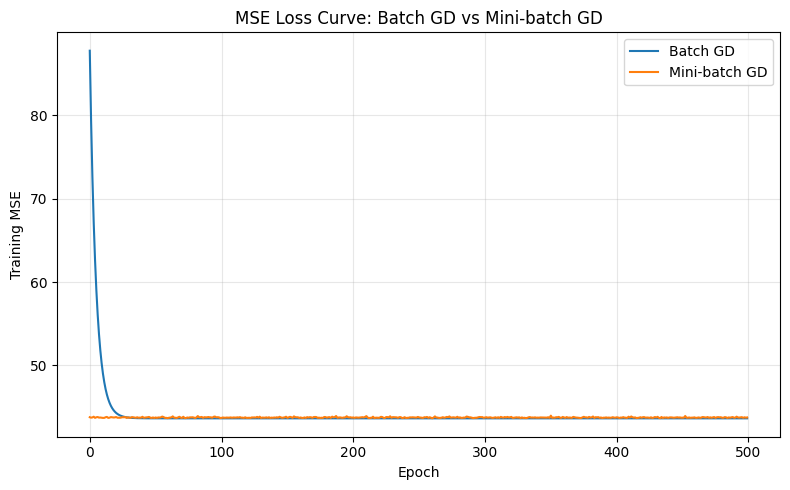

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history_gd,
    label="Batch GD"
)

plt.plot(
    loss_history_mb,
    label="Mini-batch GD"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")

plt.title(
    "MSE Loss Curve: Batch GD vs Mini-batch GD"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "loss_curve.png",
    dpi=150
)

plt.show()

In [38]:
print("\n=== RMSE Comparison ===")

print(
    f"{'Method':<20}"
    f"{'Test RMSE':>12}"
)

print(
    f"{'Batch GD':<20}"
    f"{rmse_gd:>12.4f}"
)

print(
    f"{'Mini-batch GD':<20}"
    f"{rmse_mb:>12.4f}"
)

print(
    f"{'sklearn LinearReg':<20}"
    f"{rmse_sklearn:>12.4f}"
)


=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  6.6062
Mini-batch GD             6.6134
sklearn LinearReg         6.6062
